### División de los datos

El dataset se dividió en tres conjuntos 70% entrenamiento, 15% validación y 15% para prueba. De esta manera, la distribución permite disponer de suficientes observaciones para entrenar el modelo y a su vez permite mantener conjuntos independientes para seleccionar y evaluar el modelo.

- **Entrenamiento (70%):** para ajustar los pesos de la red neuronal y entrenar los diferentes modelos.
- **Validación (15%):** para comparar las distintas combinaciones de hiperparámetros y seleccionar la mejor configuración.
- **Prueba (15%):** Se utiliza únicamente al final para evaluar el desempeño del modelo ganador sobre datos no utilizados previamente.

### Diseño del estudio de hiperparámetros

La selección de los hiperparámetros se realiza con el fin de estudiar de forma controlada algunos de los principales factores que pueden afectar el desempeño del perceptrón multicapa.

Se evaluarán los siguientes aspectos:

- Arquitectura: se comparará una red con una capa oculta de 64 neuronas frente a una red con dos capas ocultas de 64 y 32 neuronas. El objetivo es analizar si una mayor profundidad permite representar relaciones más complejas entre las características socioeconómicas y la probabilidad de que un individuo tenga ingresos superiores a $50K.
- Función de activación: se compararán las funciones ReLU y tanh. Ambas permiten introducir relaciones no lineales en la red neuronal, pero presentan diferencias en la forma en que transforman la información durante el entrenamiento.
- Tasa de aprendizaje: se mantendrá constante en 0.001 para las tres configuraciones con el fin de evitar modificar simultáneamente varios hiperparámetros.
Regularización L2: se mantendrá inicialmente en 0.001, proporcionando una penalización moderada sobre los pesos grandes y ayudando a reducir el riesgo de sobreajuste.

En síntesis, se estudiarán tres combinaciones representativas. La configuración 1 se utilizará como modelo base. La configuración 2 modificará únicamente la arquitectura, mientras que la configuración 3 modificará únicamente la función de activación respecto al modelo base. Esto permitirá interpretar de forma más clara el efecto de cada cambio sobre el desempeño.

### Entrenamiento de los modelos

Para realizar el estudio se utilizará MLPClassifier, que corresponde a la versión para clasificación del perceptrón multicapa de Scikit-learn. Se utilizará descenso de gradiente estocástico (sgd) con una tasa de aprendizaje constante.

La selección del mejor modelo se realizará exclusivamente utilizando el conjunto de validación. El conjunto de prueba se reservará para la evaluación final del modelo seleccionado.

Para evaluar el desempeño se utilizarán accuracy, precision, recall, F1 y AUC-ROC. En todas estas métricas, valores mayores representan un mejor desempeño. Además, una vez seleccionado el modelo ganador, se analizará su matriz de confusión.

In [14]:
pip install jinja2

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [20]:
# ============================================================
# PARTE 1. Preparamos datos
# ============================================================
#Importamos librerías

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.exceptions import ConvergenceWarning

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import classification_report
from sklearn.metrics import RocCurveDisplay

In [21]:
# ------------------------------------------------------------
# 1.1 Cargamos el dataset procesado
# ------------------------------------------------------------

df = pd.read_csv("../data/datos_finales.csv")

print("=" * 60)
print("Dataset utilizado para modelado")

display(df.head())

print("\nDimensiones:")
print(df.shape)

# ------------------------------------------------------------
# 1.2 Separamos predictores y variable objetivo
# ------------------------------------------------------------

X = df.drop(columns="income")
y = df["income"]

# ------------------------------------------------------------
# 1.3 Separamos entrenamiento, validación y prueba
# ------------------------------------------------------------

# Primero separamos 70% para entrenamiento y 30% para validación y prueba.

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)


# Dividimos el 30% restante en partes iguales de esta manera obtenemos 15% 
# para validación y 15% para prueba.

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

Dataset utilizado para modelado


,age,education-num,capital-gain-log,capital-loss-log,hours-per-week,workclass_Local-gov,workclass_Never-worked,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,...,native-country_Puerto-Rico,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia,income
0,-0.119879,1.136512,-0.297918,-0.221264,-2.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0
1,1.265933,-0.808297,-0.297918,4.450068,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0
2,1.047121,-0.419335,-0.297918,-0.221264,-1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0
3,2.432933,-1.197259,-0.297918,-0.221264,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0
4,0.536558,1.525474,-0.297918,-0.221264,-0.4,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0



Dimensiones:
(48842, 82)


In [22]:
# ============================================================
# PARTE 2. Diseño del estudio de hiperparámetros
# ============================================================


# ------------------------------------------------------------
# 2.1 Definimos la configuración de cada red
# ------------------------------------------------------------

# Definimos las 3 combinaciones de hiperparámetros que evaluaremos.
# Tomamos como referencia una configuración base y modificamos un
# hiperparámetro a la vez para poder estudiar de forma más controlada
# su efecto sobre el desempeño del modelo.
#
# La configuración 1 corresponde al modelo base con una capa oculta
# de 64 neuronas y función de activación ReLU.
#
# En la configuración 2 aumentamos la profundidad de la red mediante
# una segunda capa oculta. Esto permite estudiar si una arquitectura
# con mayor capacidad de representación mejora la clasificación.
#
# En la configuración 3 mantenemos la arquitectura del modelo base
# pero sustituimos ReLU por tanh. De esta manera podemos analizar
# el efecto de utilizar una función de activación diferente.
#
# La tasa de aprendizaje y la regularización L2 permanecen constantes
# en las tres configuraciones para evitar modificar simultáneamente
# varios hiperparámetros.

configs = [
    {'layers': [64], 'activation': 'relu', 'lr': 0.001, 'l2': 0.001},
    {'layers': [64, 32], 'activation': 'relu', 'lr': 0.001, 'l2': 0.001},
    {'layers': [64], 'activation': 'tanh', 'lr': 0.001, 'l2': 0.001}
]

# ------------------------------------------------------------
# 2.2 Creamos la función para entrenar el MLP
# ------------------------------------------------------------

# ------------------------------------------------------------
# 2.2 Creamos la función para entrenar el MLP
# ------------------------------------------------------------

warnings.filterwarnings('ignore', category=ConvergenceWarning)

def entrenar_mlp(arquitectura, activacion, tasa, l2, semilla=42):

    modelo = MLPClassifier(
        hidden_layer_sizes=tuple(arquitectura),
        activation=activacion,
        solver='sgd',
        learning_rate='constant',
        learning_rate_init=tasa,
        momentum=0.0,
        alpha=l2,
        batch_size=64,
        max_iter=250,
        tol=0.0,
        n_iter_no_change=250,
        shuffle=True,
        random_state=semilla
    )

    # Entrenamos utilizando únicamente el conjunto de entrenamiento
    modelo.fit(X_train, y_train)

    # Realizamos las predicciones sobre validación
    predicciones = modelo.predict(X_val)

    # Probabilidad de pertenecer a la clase positiva (>50K)
    probabilidades = modelo.predict_proba(X_val)[:, 1]

    # Calculamos las métricas de validación
    accuracy = accuracy_score(y_val, predicciones)
    precision = precision_score(y_val, predicciones)
    recall = recall_score(y_val, predicciones)
    f1 = f1_score(y_val, predicciones)
    auc = roc_auc_score(y_val, probabilidades)


    return (modelo, modelo.loss_curve_, accuracy, precision, recall, f1, auc)

# ------------------------------------------------------------
# 2.3 Realizamos el entrenamiento de las 3 configuraciones
# ------------------------------------------------------------

# Entrenamos las tres configuraciones utilizando el mismo conjunto
# de entrenamiento y el mismo conjunto de validación.
#
# La selección del modelo ganador se realizará utilizando únicamente
# las métricas obtenidas sobre validación. El conjunto de prueba no
# se utiliza durante esta etapa.

resultados = {}


for i, config in enumerate(configs, start=1):

    (
        modelo,
        curva,
        accuracy,
        precision,
        recall,
        f1,
        auc
    ) = entrenar_mlp(
        arquitectura=config['layers'],
        activacion=config['activation'],
        tasa=config['lr'],
        l2=config['l2']
    )


    resultados[i] = {
        'modelo': modelo,
        'curva': curva,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'auc': auc,
        'layers': config['layers'],
        'activation': config['activation'],
        'lr': config['lr'],
        'l2': config['l2']
    }


    print(
        f"Configuración {i} | "
        f"layers: {config['layers']} | "
        f"activación: {config['activation']} | "
        f"lr: {config['lr']} | "
        f"l2: {config['l2']} | "
        f"Accuracy: {accuracy:.3f} | "
        f"Precision: {precision:.3f} | "
        f"Recall: {recall:.3f} | "
        f"F1: {f1:.3f} | "
        f"AUC: {auc:.3f}"
    )

Configuración 1 | layers: [64] | activación: relu | lr: 0.001 | l2: 0.001 | Accuracy: 0.849 | Precision: 0.718 | Recall: 0.610 | F1: 0.660 | AUC: 0.905
Configuración 2 | layers: [64, 32] | activación: relu | lr: 0.001 | l2: 0.001 | Accuracy: 0.851 | Precision: 0.721 | Recall: 0.618 | F1: 0.665 | AUC: 0.907
Configuración 3 | layers: [64] | activación: tanh | lr: 0.001 | l2: 0.001 | Accuracy: 0.845 | Precision: 0.713 | Recall: 0.590 | F1: 0.646 | AUC: 0.901


In [23]:
# ============================================================
# PARTE 3. Resultados del estudio de hiperparámetros
# ============================================================

filas_resultados = []


for i, res in resultados.items():

    # Predicciones sobre entrenamiento
    pred_train = res['modelo'].predict(X_train)
    prob_train = res['modelo'].predict_proba(X_train)[:, 1]


    # Métricas de entrenamiento
    accuracy_train = accuracy_score(y_train, pred_train)
    precision_train = precision_score(y_train, pred_train)
    recall_train = recall_score(y_train, pred_train)
    f1_train = f1_score(y_train, pred_train)
    auc_train = roc_auc_score(y_train,prob_train)


    filas_resultados.append({
        'Configuración': i,
        'Arquitectura': str(res['layers']),
        'Activación': res['activation'],
        'Learning rate': res['lr'],
        'L2': res['l2'],
        'Accuracy entrenamiento': accuracy_train,
        'Accuracy validación': res['accuracy'],
        'Precision validación': res['precision'],
        'Recall validación': res['recall'],
        'F1 entrenamiento': f1_train,
        'F1 validación': res['f1'],
        'AUC entrenamiento': auc_train,
        'AUC validación': res['auc'],
        'Brecha F1 (Train - Val)': f1_train - res['f1']
    })


tabla_resultados = pd.DataFrame(filas_resultados)

# Ordenamos de mejor a peor utilizando F1 de validación.
# En caso de resultados similares, utilizamos AUC y posteriormente
# accuracy como criterios adicionales.

tabla_resultados = (
    tabla_resultados
    .sort_values(
        by=[
            'F1 validación',
            'AUC validación',
            'Accuracy validación'
        ],
        ascending=[
            False,
            False,
            False
        ]
    )
    .reset_index(drop=True)
)


tabla_resultados.index = (tabla_resultados.index + 1)

tabla_resultados.index.name = ('Posición')


display(
    tabla_resultados.style.format({
        'Learning rate': '{:.4f}',
        'L2': '{:.4f}',
        'Accuracy entrenamiento': '{:.3f}',
        'Accuracy validación': '{:.3f}',
        'Precision validación': '{:.3f}',
        'Recall validación': '{:.3f}',
        'F1 entrenamiento': '{:.3f}',
        'F1 validación': '{:.3f}',
        'AUC entrenamiento': '{:.3f}',
        'AUC validación': '{:.3f}',
        'Brecha F1 (Train - Val)': '{:.3f}'
    })
)

,Configuración,Arquitectura,Activación,Learning rate,L2,Accuracy entrenamiento,Accuracy validación,Precision validación,Recall validación,F1 entrenamiento,F1 validación,AUC entrenamiento,AUC validación,Brecha F1 (Train - Val)
Posición,,,,,,,,,,,,,,
1,2,"[64, 32]",relu,0.0010,0.0010,0.853,0.851,0.721,0.618,0.663,0.665,0.908,0.907,-0.003
2,1,[64],relu,0.0010,0.0010,0.850,0.849,0.718,0.610,0.659,0.660,0.906,0.905,-0.001
3,3,[64],tanh,0.0010,0.0010,0.847,0.845,0.713,0.590,0.650,0.646,0.902,0.901,0.004


In [24]:
# ============================================================
# PARTE 4. Evaluación final del modelo seleccionado
# ============================================================

# La configuración ganadora fue la Configuración 1 que contiene las siguientes
# caracteristicas: Contiene una capa oculta de 64 neurona, una función de activación ReLU, un
# Learning rate de 0.001 y una regularización L2 0.001. 
#
# Esta configuración fue seleccionada utilizando únicamente el conjunto de validación.
# A partir de este punto utilizamos el conjunto de prueba para evaluar el desempeño 
# final del modelo.


# Recuperamos el modelo ganador
modelo_final = resultados[2]['modelo']


# Realizamos las predicciones sobre el conjunto de prueba
y_pred_test = modelo_final.predict(X_test)

# Obtenemos la probabilidad de pertenecer a la clase positiva (>50K)
y_prob_test = modelo_final.predict_proba(X_test)[:, 1]

# Calculamos las métricas de evaluación
accuracy_test = accuracy_score(y_test, y_pred_test)
precision_test = precision_score(y_test,y_pred_test)
recall_test = recall_score(y_test,y_pred_test)
f1_test = f1_score(y_test, y_pred_test)
auc_test = roc_auc_score(y_test, y_prob_test)


print("=" * 60)
print("esultados finales del MLP")
print(f"Accuracy: {accuracy_test:.3f}")
print(f"Precision: {precision_test:.3f}")
print(f"Recall: {recall_test:.3f}")
print(f"F1: {f1_test:.3f}")
print(f"AUC-ROC: {auc_test:.3f}")

esultados finales del MLP
Accuracy: 0.853
Precision: 0.727
Recall: 0.619
F1: 0.669
AUC-ROC: 0.911


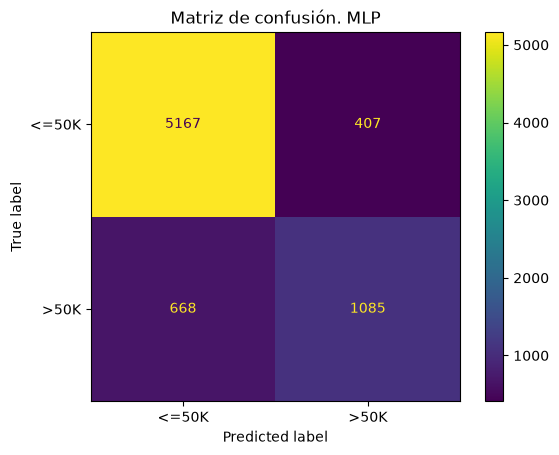

In [25]:
# ------------------------------------------------------------
# 4.4 Matriz de confusión
# ------------------------------------------------------------

matriz_confusion = confusion_matrix(y_test, y_pred_test)
disp = ConfusionMatrixDisplay(confusion_matrix=matriz_confusion, display_labels=["<=50K", ">50K"])
disp.plot()
plt.title("Matriz de confusión. MLP")
plt.show()

### Análisis de resultados del modelo seleccionado como ganador

En este caso el modelo ganador resulto ser la configuración 2. Esta configuración contiene las siguientes caracteristicas: Contiene dos capas ocultas de 64 neuronas y 32 neuronas resectivamente, una función de activación ReLU, un Learning rate de 0.001 y una regularización L2 0.001. 

Ahora bien, al moemnto que evaluamos el modelo seleccionado vemos que se obtuvo una exactitud de 85.3%, lo que quiere decir que el perceptrón clasifico correctamente 85 de cada 100 observaciones. Se debe recordar que debido al desequilibrio existente entre las clases, la exactitud por sí sola no resulta suficiente para valorar el desempeño del modelo por lo que también se analizar precision, recall y F1. Con respecto a la precisión se obtuvo un valor de 72.7%, lo que significa que del total de personas que el modelo clasificó como personas con ingresos superiores a $50K, alrededor del 73% pertenecía realmente a esta categoría. En cuanto al recall, se obtuvo un valor de 61.9%, lo que se traduce a que el modelo logró identificar de forma correcta al 61.9% de todos las observaciones que realmente cuentan con ingresos superiores a USD $50K. Esto evidencia que el modelo tiene una dificultad mayor a la hora de detectar la clase minoritaria. El F1 , que resume el equilibrio entre precision y recall,  fue de 0.669 lo que indica que aun hay margen de mejora en la capacidad del modelo para recuperar las observaciones pretenecientes a la clase de individuos de mayor ingreso. Finalmente, el AUC-ROC de 0.911 evidencia una buena capacidad de discriminación. Lo que significa que el modelo logra separar adecuadamente a los individuos con ingresos superiores a $50K de aquellos con ingresos iguales o inferiores a este nivel.

En lo que respecta a la matriz de confusión, podemos observar que Se clasificaron correctamente 5167 individuos con ingresos iguales o inferiores a $50K y 1085 individuos con ingresos superiores a $50K. Además, se registraron 407 falsos positivos (personas clasificadas como >50K cuando realmente pertenecían a <=50K) y 668 falsos negativos (personas clasificadas como <50K cuando realmente pertenecían a >=50K). Así, podemos concluir que al existir un mayor número de falsos negativos que de falsos positivos demuestra como principal limitante del modelo la identificación de la clase >50K. 

En síntesis, el perceptrón multicapa presenta un buen desempeño global, especialmente considerando la exactitud cercana al 85% y el AUC-ROC de 0.911. Sin embargo, el análisis de la matriz de confusión y del recall muestra que el modelo todavía tiene dificultades para identificar una parte importante de los individuos con ingresos superiores a $50K. Por esta razón, la evaluación del MLP debe considerar conjuntamente accuracy, precision, recall, F1 y AUC-ROC, y no basarse únicamente en una métrica. Así, en la comparación final con los demás modelos del proyecto, será importante verificar si algún algoritmo logra mantener un AUC-ROC similar o superior, pero al mismo tiempo mejorar el recall y el F1 de la clase >50K, ya que eso representaría una mejor identificación de la clase minoritaria.